In [1]:
# Run once at top of notebook
!pip install xgboost shap lime --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import joblib
import xgboost as xgb
import shap


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/delhi_aqi.csv')


In [4]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2020-11-25 1:00:00,2616.88,2.18,70.60,13.59,38.62,364.61,411.73,28.63
1,2020-11-25 2:00:00,3631.59,23.25,89.11,0.33,54.36,420.96,486.21,41.04
2,2020-11-25 3:00:00,4539.49,52.75,100.08,1.11,68.67,463.68,541.95,49.14
3,2020-11-25 4:00:00,4539.49,50.96,111.04,6.44,78.20,454.81,534.00,48.13
4,2020-11-25 5:00:00,4379.27,42.92,117.90,17.17,87.74,448.14,529.19,46.61


In [5]:
df.shape


(18776, 9)

In [6]:
df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

In [7]:
df.isnull().sum()


,0
date,0
co,0
no,0
no2,0
o3,0
so2,0
pm2_5,0
pm10,0
nh3,0


In [8]:
df.dtypes

,0
date,object
co,float64
no,float64
no2,float64
o3,float64
so2,float64
pm2_5,float64
pm10,float64
nh3,float64


In [9]:
df['date'] = pd.to_datetime(df['date'])
df.dtypes


,0
date,datetime64[ns]
co,float64
no,float64
no2,float64
o3,float64
so2,float64
pm2_5,float64
pm10,float64
nh3,float64


In [10]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour


In [11]:
df.head()
df.describe()


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,year,month,day,hour
count,18776,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000
mean,2021-12-23 14:35:34.384320256,2929.228628,33.660702,66.221299,60.346239,66.693633,238.130309,300.092966,25.109815,2021.470121,6.609608,15.678259,11.497017
min,2020-11-25 01:00:00,260.350000,0.000000,4.280000,0.000000,5.250000,11.830000,15.070000,0.000000,2020.000000,1.000000,1.000000,0.000000
25%,2021-06-09 14:45:00,1068.120000,0.680000,33.930000,0.340000,34.810000,84.440000,118.797500,9.630000,2021.000000,3.000000,8.000000,5.000000
50%,2021-12-22 04:30:00,1842.500000,5.250000,54.150000,27.180000,52.930000,157.445000,209.705000,17.480000,2021.000000,7.000000,16.000000,11.000000
75%,2022-07-07 18:15:00,3685.000000,35.760000,83.630000,92.980000,82.020000,313.000000,387.965000,30.400000,2022.000000,10.000000,23.000000,17.000000
max,2023-01-24 08:00:00,21148.680000,500.680000,460.620000,801.090000,579.830000,1708.090000,1969.930000,287.770000,2023.000000,12.000000,31.000000,23.000000
std,NaN,2854.523506,62.127118,48.527492,80.464932,49.439191,226.533625,267.165827,26.402108,0.635113,3.621966,8.812657,6.922565


In [12]:
def calculate_individual_aqi(concentration, breakpoints):
    for bp in breakpoints:
        if bp["low"] <= concentration <= bp["high"]:
            aqi = ((bp["aqi_high"] - bp["aqi_low"]) / (bp["high"] - bp["low"])) \
                * (concentration - bp["low"]) + bp["aqi_low"]
            return aqi
    return None


In [13]:
pm25_breakpoints = [
    {"low": 0,   "high": 30,  "aqi_low": 0,   "aqi_high": 50},
    {"low": 31,  "high": 60,  "aqi_low": 51,  "aqi_high": 100},
    {"low": 61,  "high": 90,  "aqi_low": 101, "aqi_high": 200},
    {"low": 91,  "high": 120, "aqi_low": 201, "aqi_high": 300},
    {"low": 121, "high": 250, "aqi_low": 301, "aqi_high": 400},
    {"low": 251, "high": 1000,"aqi_low": 401, "aqi_high": 500},
]

pm10_breakpoints = [
    {"low": 0,   "high": 50,   "aqi_low": 0,   "aqi_high": 50},
    {"low": 51,  "high": 100,  "aqi_low": 51,  "aqi_high": 100},
    {"low": 101, "high": 250,  "aqi_low": 101, "aqi_high": 200},
    {"low": 251, "high": 350,  "aqi_low": 201, "aqi_high": 300},
    {"low": 351, "high": 430,  "aqi_low": 301, "aqi_high": 400},
    {"low": 431, "high": 1000, "aqi_low": 401, "aqi_high": 500},
]


In [14]:
df['AQI_PM25'] = df['pm2_5'].apply(lambda x: calculate_individual_aqi(x, pm25_breakpoints))
df['AQI_PM10'] = df['pm10'].apply(lambda x: calculate_individual_aqi(x, pm10_breakpoints))

df['AQI'] = df[['AQI_PM25', 'AQI_PM10']].max(axis=1)


In [15]:
df['AQI'].describe()

,AQI
count,18500.000000
mean,294.437729
std,132.957608
min,19.716667
25%,177.503103
50%,326.690116
75%,407.948835
max,499.989426


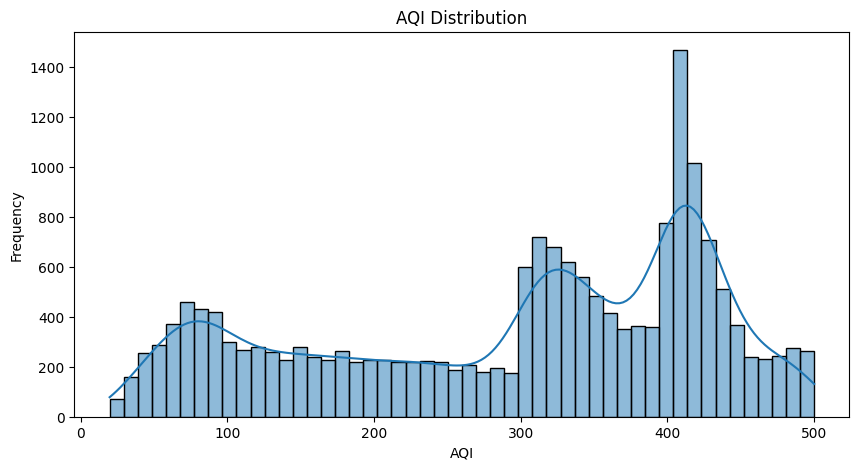

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['AQI'], bins=50, kde=True)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


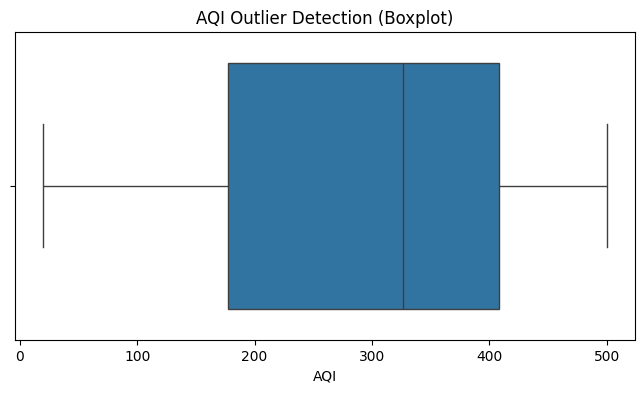

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['AQI'])
plt.title("AQI Outlier Detection (Boxplot)")
plt.show()


In [18]:
df['AQI'].describe()


,AQI
count,18500.000000
mean,294.437729
std,132.957608
min,19.716667
25%,177.503103
50%,326.690116
75%,407.948835
max,499.989426


In [19]:
df[df['AQI'] < 50].head()


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,year,month,day,hour,AQI_PM25,AQI_PM10,AQI
3006,2021-03-31 07:00:00,467.30,1.03,7.97,177.38,15.74,29.56,41.05,8.87,2021,3,31,7,49.266667,41.05,49.266667
3007,2021-03-31 08:00:00,417.23,0.92,6.94,174.52,12.64,22.85,31.83,7.09,2021,3,31,8,38.083333,31.83,38.083333
3008,2021-03-31 09:00:00,413.90,0.89,7.03,175.95,12.28,22.07,30.34,7.03,2021,3,31,9,36.783333,30.34,36.783333
3009,2021-03-31 10:00:00,433.92,0.94,8.23,174.52,13.11,23.43,31.65,7.66,2021,3,31,10,39.050000,31.65,39.050000
3010,2021-03-31 11:00:00,467.30,1.03,11.14,170.23,15.50,24.21,32.14,8.49,2021,3,31,11,40.350000,32.14,40.350000


In [20]:
(df['AQI'] < 50).sum()


np.int64(525)

In [21]:
# assume df already exists in your notebook (you loaded from Drive earlier)
print("shape:", df.shape)
print("columns:", df.columns.tolist())
print(df[['date','pm2_5','pm10','no2','o3','co','so2','nh3']].head())
# ensure datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)


shape: (18776, 16)
columns: ['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'year', 'month', 'day', 'hour', 'AQI_PM25', 'AQI_PM10', 'AQI']
                 date   pm2_5    pm10     no2     o3       co    so2    nh3
0 2020-11-25 01:00:00  364.61  411.73   70.60  13.59  2616.88  38.62  28.63
1 2020-11-25 02:00:00  420.96  486.21   89.11   0.33  3631.59  54.36  41.04
2 2020-11-25 03:00:00  463.68  541.95  100.08   1.11  4539.49  68.67  49.14
3 2020-11-25 04:00:00  454.81  534.00  111.04   6.44  4539.49  78.20  48.13
4 2020-11-25 05:00:00  448.14  529.19  117.90  17.17  4379.27  87.74  46.61


In [22]:
lag_cols = ['pm2_5','pm10','no2','o3','co','so2','nh3']
max_lag = 24

# create lag features: col_lag1 is value 1 hour before
for col in lag_cols:
    for lag in range(1, max_lag+1):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# target: pm2_5 at t+1 (1-hour ahead)
df['pm2_5_t_plus_1'] = df['pm2_5'].shift(-1)

# drop rows with NaNs created by lagging or target shift
df_model = df.dropna().reset_index(drop=True)
print("After lagging and dropna:", df_model.shape)


/tmp/ipython-input-1107107731.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag{lag}'] = df[col].shift(lag)
/tmp/ipython-input-1107107731.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag{lag}'] = df[col].shift(lag)
/tmp/ipython-input-1107107731.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, u

After lagging and dropna: (17690, 185)


In [23]:
# adjust depending on your dataset date range; this uses calendar-year split
train_cutoff = pd.Timestamp('2023-01-01')

train_df = df_model[df_model['date'] < train_cutoff].copy()
test_df  = df_model[df_model['date'] >= train_cutoff].copy()

print("train:", train_df.shape, "test:", test_df.shape)


train: (17168, 185) test: (522, 185)


In [24]:
feature_cols = [c for c in df_model.columns if ('_lag' in c)] + ['hour','day','month']
# ensure time features exist
if 'hour' not in df_model.columns:
    df_model['hour'] = df_model['date'].dt.hour
    df_model['day'] = df_model['date'].dt.day
    df_model['month'] = df_model['date'].dt.month
    train_df['hour'] = train_df['date'].dt.hour
    train_df['day'] = train_df['date'].dt.day
    train_df['month'] = train_df['date'].dt.month
    test_df['hour'] = test_df['date'].dt.hour
    test_df['day'] = test_df['date'].dt.day
    test_df['month'] = test_df['date'].dt.month

X_train = train_df[feature_cols]
y_train = train_df['pm2_5_t_plus_1']
X_test  = test_df[feature_cols]
y_test  = test_df['pm2_5_t_plus_1']

print("X shape:", X_train.shape, X_test.shape)


X shape: (17168, 171) (522, 171)


In [26]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------- XGBOOST MODEL ----------------
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist',
    verbosity=0
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# ---------------- FIXED METRICS FUNCTION ----------------
def print_metrics(y_true, y_pred, prefix=""):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)   # ✅ compatible with ALL sklearn versions
    r2  = r2_score(y_true, y_pred)
    print(f"{prefix} MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

# Print Results
print_metrics(y_test, y_pred_xgb, prefix="XGBoost")


XGBoost MAE: 41.097, RMSE: 60.781, R2: 0.876


 98%|===================| 1967/2000 [00:26<00:00]       

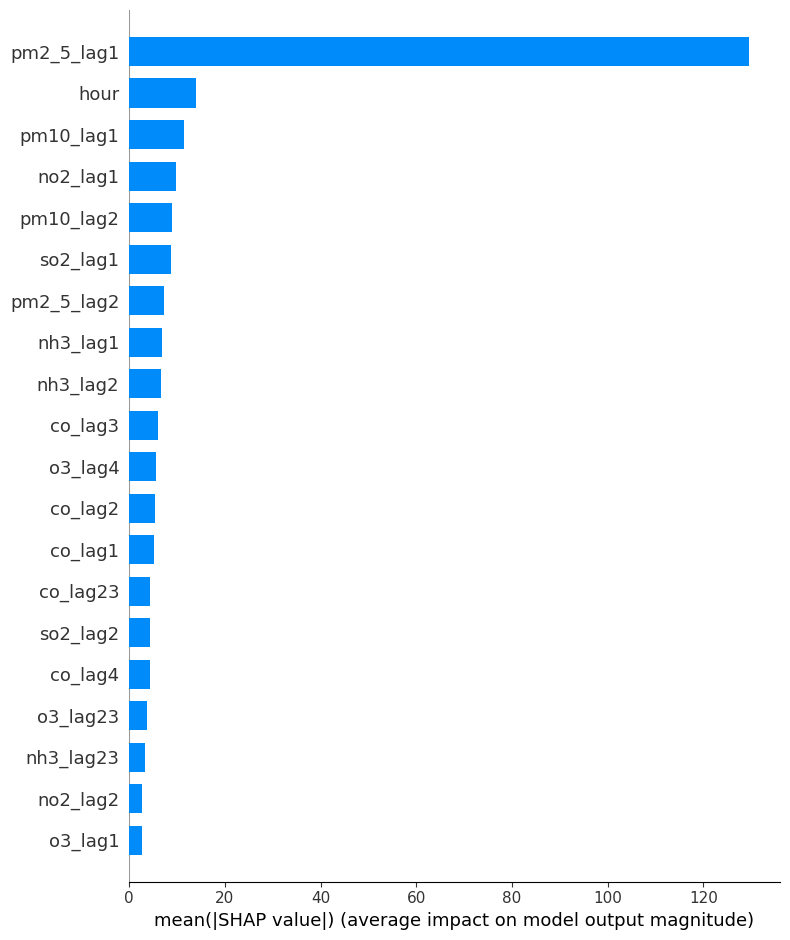

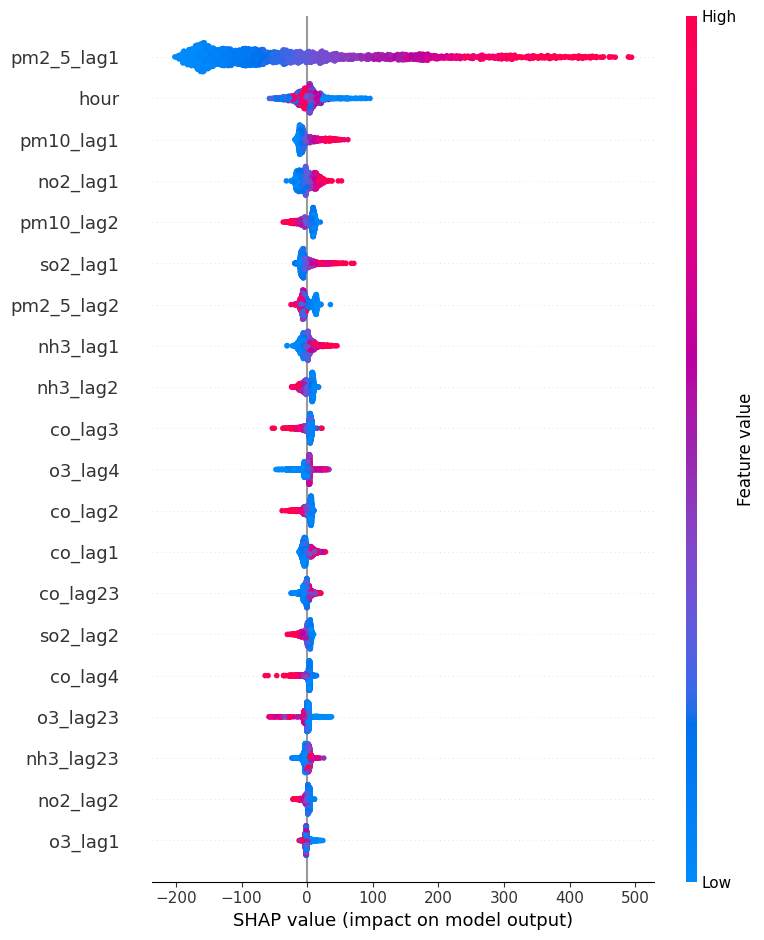

In [27]:
# use sample for speed
sample_idx = np.random.choice(X_train.shape[0], size=min(2000, X_train.shape[0]), replace=False)
X_sample = X_train.iloc[sample_idx]

# For XGBoost:
explainer = shap.Explainer(xgb_model, X_sample)
shap_values = explainer(X_sample)

# global summary
shap.summary_plot(shap_values, X_sample, plot_type="bar")  # bar plot of mean abs SHAP

# detailed beeswarm (may be heavier)
shap.summary_plot(shap_values, X_sample)


In [29]:
joblib.dump(xgb_model, '/content/drive/MyDrive/xgb_pm25_model_1hr.pkl')
#joblib.dump(rf, '/content/drive/MyDrive/rf_pm25_model_1hr.pkl')
print("Saved models to Drive.")


Saved models to Drive.


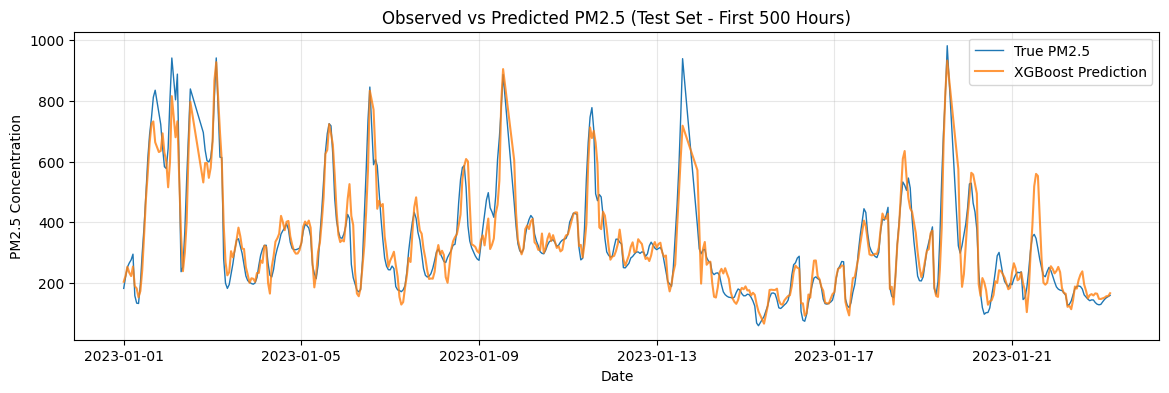

In [30]:
# create a small df for visual inspection (first N points)
plot_df = test_df[['date']].copy()
plot_df['y_true'] = y_test.values
plot_df['xgb_pred'] = y_pred_xgb

plt.figure(figsize=(14,4))
plt.plot(plot_df['date'].iloc[:500], plot_df['y_true'].iloc[:500], label='True PM2.5', linewidth=1)
plt.plot(plot_df['date'].iloc[:500], plot_df['xgb_pred'].iloc[:500], label='XGBoost Prediction', alpha=0.8)

plt.legend()
plt.title("Observed vs Predicted PM2.5 (Test Set - First 500 Hours)")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")
plt.grid(alpha=0.3)
plt.show()

